# **EXP03: Chunking Strategy Analysis**

### Objective: Determine whether context-aware chunking imrpove retrieval
### Variables: `Fixed` vs `Recursive` vs `Sentence`


```
Entities: all-MiniLM-L6-v2, Dense Retriever, No Reranker
```



#### GPU Check

In [1]:
import torch

print("=" * 50)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA Available: True
GPU: Tesla T4


#### Clone Repository

In [2]:
!git clone https://github.com/ver1619/rag-bench.git
%cd rag-bench

Cloning into 'rag-bench'...
remote: Enumerating objects: 257, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 257 (delta 25), reused 23 (delta 12), pack-reused 214 (from 1)
Receiving objects: 100% (257/257), 64.09 MiB | 17.92 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/rag-bench


#### Dependencies

In [3]:
!pip install -q langchain-text-splitters nltk pymupdf sentence-transformers \
    torch qdrant-client rank-bm25 python-dotenv matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 26.1 MB/s eta 0:00:00


#### Qdrant Cloud Connection

In [4]:
from google.colab import userdata
from qdrant_client import QdrantClient

QDRANT_URL = userdata.get("QDRANT_URL")
QDRANT_API_KEY = userdata.get("QDRANT_API_KEY")

cloud_client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)

print("✅ Connected to Qdrant Cloud")

✅ Connected to Qdrant Cloud


#### 1. Define Chunkers

In [5]:
CHUNKERS = ["fixed", "recursive", "sentence"]
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

#### 2. Build + Index + Evaluate Loop

In [6]:
import json
import time
from pathlib import Path

from src.pipeline.factory import create_pipeline_builder
from src.ingestion.service import ingest_documents
from src.indexing.service import IndexingService
from src.vectordb.qdrant import QdrantVectorStore

from src.retrieval.factory import create_dense_retriever
from src.retrieval.pipeline import RetrievalPipeline

from src.evaluation.dataset import EvaluationDataset
from src.evaluation.latency import Latency
from src.evaluation.runner import EvaluationRunner
from src.evaluation.metrics import (
    RecallAtK,
    PrecisionAtK,
    MeanReciprocalRank,
    NormalizedDiscountedCumulativeGain,
)

# Patch vector store for Qdrant Cloud
vector_store = QdrantVectorStore.__new__(QdrantVectorStore)
vector_store.host = QDRANT_URL
vector_store.port = 6333
vector_store.client = cloud_client

metrics = [
    RecallAtK(),
    PrecisionAtK(),
    MeanReciprocalRank(),
    NormalizedDiscountedCumulativeGain(),
]

dataset = EvaluationDataset("data/queries/queries.json")

results = {}

for chunker_name in CHUNKERS:

    collection = f"exp03_{chunker_name}"

    print(f"\n{'='*60}")
    print(f"Chunker: {chunker_name}")
    print(f"Collection: {collection}")
    print(f"{'='*60}")

    # Write config
    config_path = Path("data/metadata/config.json")
    config_path.parent.mkdir(parents=True, exist_ok=True)
    with config_path.open("w") as f:
        json.dump({
            "embedding_model": EMBEDDING_MODEL,
            "chunker": chunker_name,
        }, f, indent=4)

    # Build pipeline
    build_start = time.perf_counter()

    builder = create_pipeline_builder(
        model_name=EMBEDDING_MODEL,
        chunker=chunker_name,
    )
    pipeline = builder.build()

    build_time = time.perf_counter() - build_start

    chunk_count = len(pipeline.chunks)
    print(f"Chunks     : {chunk_count}")
    print(f"Build Time : {build_time:.2f}s")

    # Index
    indexer = IndexingService(
        vector_store=vector_store,
        collection_name=collection,
    )

    indexer.index(
        embeddings=pipeline.embeddings,
        overwrite=True,
    )

    # Evaluate
    retriever = create_dense_retriever(
        vector_store=vector_store,
        embedder=builder.embedder,
        collection_name=collection,
    )

    retrieval_pipeline = RetrievalPipeline(
        retriever=retriever,
        reranker=None,
    )

    runner = EvaluationRunner(
        retrieval_pipeline=retrieval_pipeline,
        dataset=dataset,
        metrics=metrics,
        latency=Latency(),
    )

    benchmark = runner.run(top_k=5)
    s = benchmark.summary

    results[chunker_name.title()] = {
        "Recall@5": s.recall,
        "Precision@5": s.precision,
        "MRR": s.mrr,
        "nDCG@5": s.ndcg,
        "Latency (ms)": s.latency_ms,
        "Chunk Count": chunk_count,
        "Build Time (s)": round(build_time, 2),
    }

    print(f"Recall@5  : {s.recall:.4f}")
    print(f"nDCG@5    : {s.ndcg:.4f}")

    # Cleanup
    cloud_client.delete_collection(collection)
    print(f"✅ Collection '{collection}' deleted")

print("\n✅ All chunking strategies evaluated")


Chunker: fixed
Collection: exp03_fixed


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/241 [00:00<?, ?it/s]

Chunks     : 30727
Build Time : 120.40s

Uploading 30727 embeddings in 121 batches...

[  1/121] Indexed 256 vectors
[  2/121] Indexed 256 vectors
[  3/121] Indexed 256 vectors
[  4/121] Indexed 256 vectors
[  5/121] Indexed 256 vectors
[  6/121] Indexed 256 vectors
[  7/121] Indexed 256 vectors
[  8/121] Indexed 256 vectors
[  9/121] Indexed 256 vectors
[ 10/121] Indexed 256 vectors
[ 11/121] Indexed 256 vectors
[ 12/121] Indexed 256 vectors
[ 13/121] Indexed 256 vectors
[ 14/121] Indexed 256 vectors
[ 15/121] Indexed 256 vectors
[ 16/121] Indexed 256 vectors
[ 17/121] Indexed 256 vectors
[ 18/121] Indexed 256 vectors
[ 19/121] Indexed 256 vectors
[ 20/121] Indexed 256 vectors
[ 21/121] Indexed 256 vectors
[ 22/121] Indexed 256 vectors
[ 23/121] Indexed 256 vectors
[ 24/121] Indexed 256 vectors
[ 25/121] Indexed 256 vectors
[ 26/121] Indexed 256 vectors
[ 27/121] Indexed 256 vectors
[ 28/121] Indexed 256 vectors
[ 29/121] Indexed 256 vectors
[ 30/121] Indexed 256 vectors
[ 31/121] Ind

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/241 [00:00<?, ?it/s]

Chunks     : 30814
Build Time : 105.98s

Uploading 30814 embeddings in 121 batches...

[  1/121] Indexed 256 vectors
[  2/121] Indexed 256 vectors
[  3/121] Indexed 256 vectors
[  4/121] Indexed 256 vectors
[  5/121] Indexed 256 vectors
[  6/121] Indexed 256 vectors
[  7/121] Indexed 256 vectors
[  8/121] Indexed 256 vectors
[  9/121] Indexed 256 vectors
[ 10/121] Indexed 256 vectors
[ 11/121] Indexed 256 vectors
[ 12/121] Indexed 256 vectors
[ 13/121] Indexed 256 vectors
[ 14/121] Indexed 256 vectors
[ 15/121] Indexed 256 vectors
[ 16/121] Indexed 256 vectors
[ 17/121] Indexed 256 vectors
[ 18/121] Indexed 256 vectors
[ 19/121] Indexed 256 vectors
[ 20/121] Indexed 256 vectors
[ 21/121] Indexed 256 vectors
[ 22/121] Indexed 256 vectors
[ 23/121] Indexed 256 vectors
[ 24/121] Indexed 256 vectors
[ 25/121] Indexed 256 vectors
[ 26/121] Indexed 256 vectors
[ 27/121] Indexed 256 vectors
[ 28/121] Indexed 256 vectors
[ 29/121] Indexed 256 vectors
[ 30/121] Indexed 256 vectors
[ 31/121] Ind

#### 3. Results Table

In [7]:
import pandas as pd

df = pd.DataFrame(results).T
df.index.name = "Chunker"
print(df.to_string(float_format="%.4f"))

           Recall@5  Precision@5    MRR  nDCG@5  Latency (ms)  Chunk Count  Build Time (s)
Chunker                                                                                   
Fixed        0.3498       0.3080 0.3530  0.3537      185.2656   30742.0000         91.9700
Recursive    0.3612       0.3027 0.3606  0.3628      189.2718   30727.0000        120.4000
Sentence     0.3498       0.3070 0.3555  0.3536      196.0281   30814.0000        105.9800


#### 4. Metrics

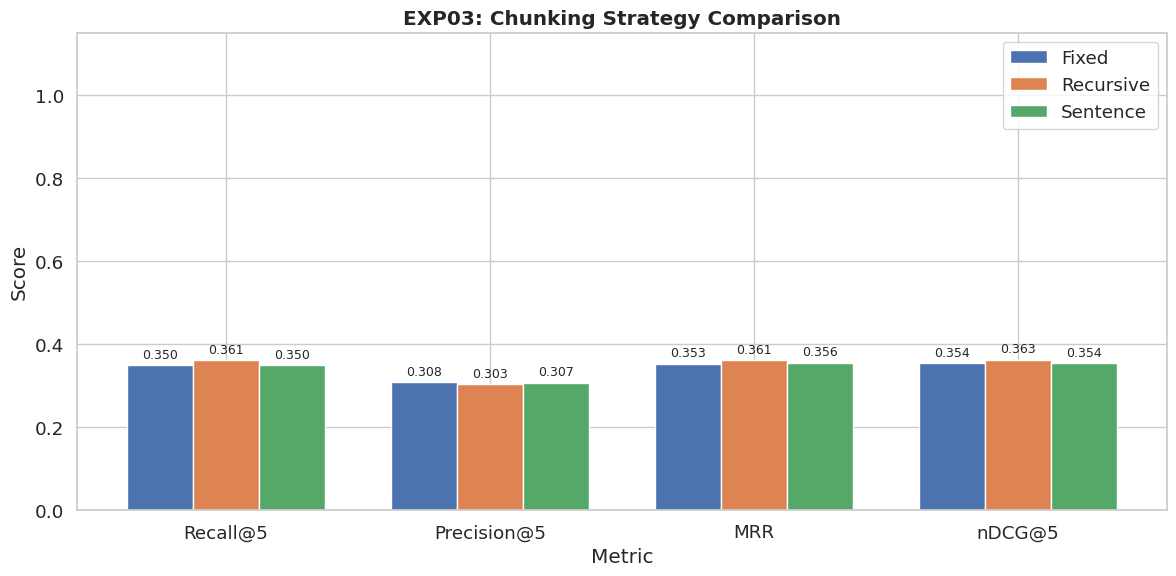

✅ Chart saved: exp03_chunk_metrics.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.2)

metric_cols = ["Recall@5", "Precision@5", "MRR", "nDCG@5"]
chunkers = list(results.keys())

x = np.arange(len(metric_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, chunker in enumerate(chunkers):
    values = [results[chunker][m] for m in metric_cols]
    bars = ax.bar(x + i * width, values, width, label=chunker)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("EXP03: Chunking Strategy Comparison", fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.15)
ax.legend()

plt.tight_layout()
plt.savefig("exp03_chunk_metrics.png", dpi=150)
plt.show()

print("✅ Chart saved: exp03_chunk_metrics.png")

#### 5. Chunk Count Comparison

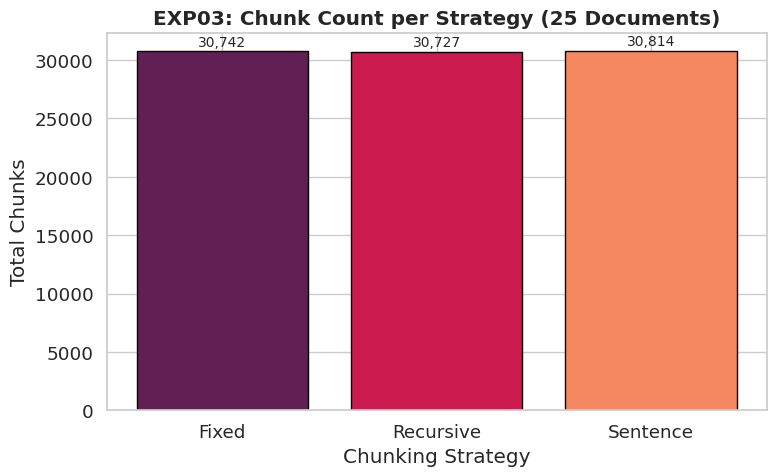

✅ Chart saved: exp03_chunk_counts.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = [results[c]["Chunk Count"] for c in chunkers]
colors = sns.color_palette("rocket", len(chunkers))

bars = ax.bar(chunkers, counts, color=colors, edgecolor="black")

for bar, val in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{int(val):,}",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_xlabel("Chunking Strategy")
ax.set_ylabel("Total Chunks")
ax.set_title("EXP03: Chunk Count per Strategy (25 Documents)", fontweight="bold")

plt.tight_layout()
plt.savefig("exp03_chunk_counts.png", dpi=150)
plt.show()

print("✅ Chart saved: exp03_chunk_counts.png")